In [31]:
import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
from math import sqrt, pi, e
import seaborn as sns

<h1>Zadanie 1</h1>

In [15]:
def statystyki(X):
    X = np.array(X)
    s = dict()

    X_sorted = sorted(X) #mediana
    if len(X)%2 == 0: s["mediana"] = (X_sorted[len(X)//2 - 1]+X_sorted[len(X)//2])/2
    else: s["mediana"] = X_sorted[len(X)//2]

    X_bottom = X_sorted[:len(X)//2]
    X_top = X_sorted[len(X)//2:]
    if len(X)%2 == 1: X_top = X_top[1:] #nie bierzemy Q2

    if len(X_bottom)%2 == 0: s["Q1"] = (X_bottom[len(X_bottom)//2 - 1]+X_bottom[len(X_bottom)//2])/2
    else: s["Q1"] = X_bottom[len(X_bottom)//2]

    if len(X_top)%2 == 0: s["Q3"] = (X_top[len(X_top)//2 - 1]+X_top[len(X_top)//2])/2
    else: s["Q3"] = X_top[len(X_top)//2]

    s["rozstep"] = max(X)-min(X)
    s["IQR"] = s["Q3"]-s["Q1"]

    s["srednia"] = sum(X)/len(X)
    s["Var"] = sum((X-s["srednia"])**2)/(len(X)-1)
    s["sigma"] = sqrt(s["Var"])

    s["kurtoza"] = sp.stats.kurtosis(X)
    s["skosnosc"] = sp.stats.skew(X)

    return s

tab = sp.stats.norm.rvs(loc=2,scale=2,size=2000)
s = statystyki(tab)
print(s["mediana"], s["Q1"], s["Q3"], "\n",
      s["rozstep"], s["IQR"], s["Var"], s["sigma"])


2.0145118545352805 0.7188994240295682 3.3422694707559764 
 13.863719804916494 2.623370046726408 3.93447097426498 1.9835500937120243


<h1>Zadanie 2</h1>

In [10]:
nyse = pd.read_csv("NYSESW.csv")

print("arytmetyczna", nyse["dat"].mean())
print("harmoniczna", sp.stats.hmean(nyse["dat"]))
print("geometryczna", sp.stats.mstats.gmean(nyse["dat"]))

nyse["rownames"] = nyse["rownames"].apply(lambda x: pd.to_datetime(x))
nyse.tail()
#wykresy

arytmetyczna 4603.581661254059
harmoniczna 3768.1003255130945
geometryczna 4185.885026781533


,rownames,dat
3998,2005-11-07,7519.42
3999,2005-11-08,7489.72
4000,2005-11-09,7500.99
4001,2005-11-10,7530.13
4002,2005-11-11,7561.40


<h1>Zadanie 3</h1>

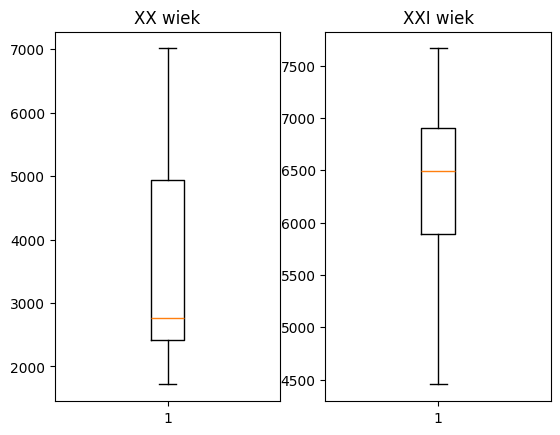

In [11]:
nyse_xx = nyse[nyse["rownames"] < "01-01-2000"]
nyse_xxi = nyse[nyse["rownames"] >= "01-01-2000"]

plt.boxplot
fig, ax = plt.subplots(ncols=2)
ax[0].boxplot(nyse_xx["dat"])
ax[0].set_title("XX wiek")
ax[1].boxplot(nyse_xxi["dat"])
ax[1].set_title("XXI wiek")
plt.show()

<Axes: ylabel='dat'>

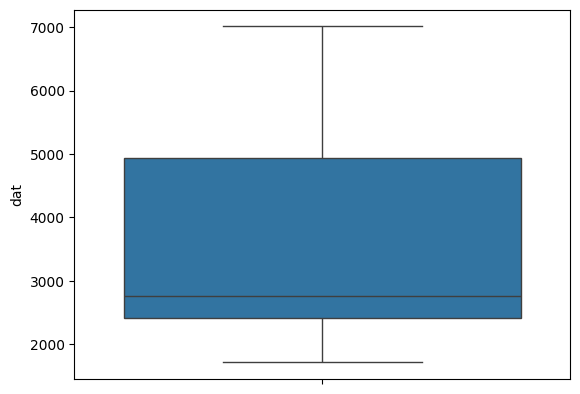

In [14]:
sns.boxplot(data=nyse_xx, y="dat")

<h1>Zadanie 4</h1>
Statystyki

In [22]:
norm = sp.stats.norm.rvs(loc=10,scale=5,size=1000)
norm2 = np.append(norm, sp.stats.uniform.rvs(loc=50,scale=50,size=10))
print("ROZKŁAD 1 (1000 elementów) | ROZKŁAD 2 (1010 elementów)")
s1, s2 = statystyki(norm), statystyki(norm2)
print("średnia:", s1["srednia"], "|", s2["srednia"])
print("mediana:", s1["mediana"], "|", s2["mediana"])
print("IQR:", s1["IQR"], "|", s2["IQR"])
print("Var:", s1["Var"], "|", s2["Var"])
print("odchylenie standardowe:", s1["sigma"], "|", s2["sigma"])
print("kurtoza:", s1["kurtoza"], "|", s2["kurtoza"])
print("skośność:", s1["skosnosc"], "|", s2["skosnosc"])

ROZKŁAD 1 (1000 elementów) | ROZKŁAD 2 (1010 elementów)
średnia: 10.086716976604828 | 10.755883453003822
mediana: 10.029051612694953 | 10.08133898041888
IQR: 6.104085076000052 | 6.22226647347197
Var: 22.08449620476754 | 69.16013910378038
odchylenie standardowe: 4.6994144533939055 | 8.316257517885097
kurtoza: 0.04206183950065334 | 52.305109193646196
skośność: -0.047828347141609925 | 5.920393386710869


Histogramy

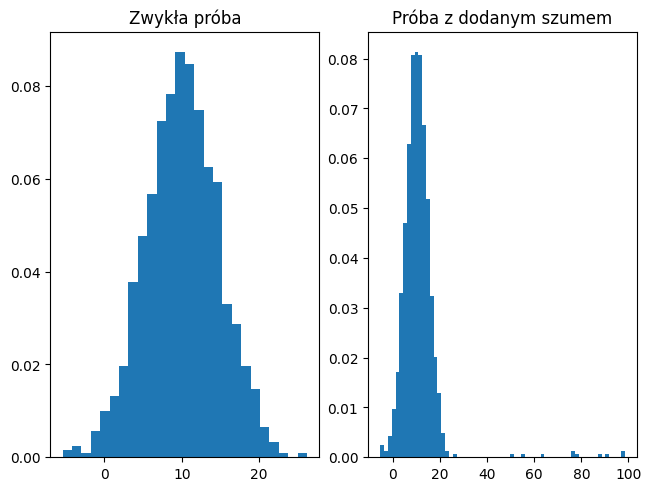

In [26]:
fig, ax = plt.subplots(ncols=2, constrained_layout=True)

ax[0].hist(norm, density=True, bins="auto")
ax[0].set_title("Zwykła próba")
ax[1].hist(norm2, density=True, bins="auto")
ax[1].set_title("Próba z dodanym szumem")

plt.show()

Wykresy pudełkowe

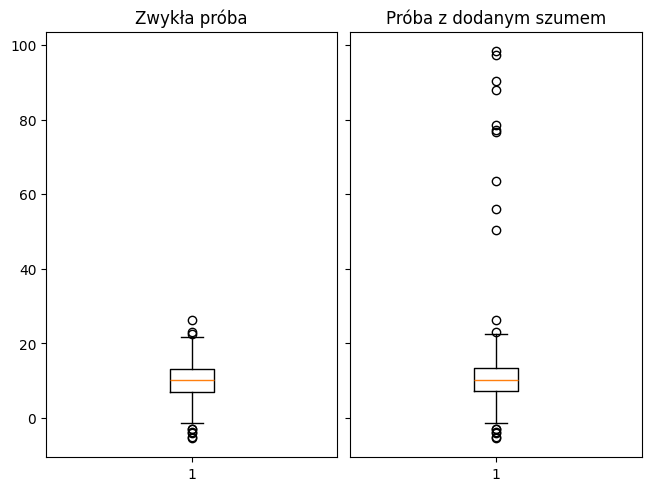

In [29]:
fig, ax = plt.subplots(ncols=2, constrained_layout=True, sharey=True)

ax[0].boxplot(norm)
ax[0].set_title("Zwykła próba")
ax[1].boxplot(norm2)
ax[1].set_title("Próba z dodanym szumem")

plt.show()

<h1>Zadanie 5</h1>

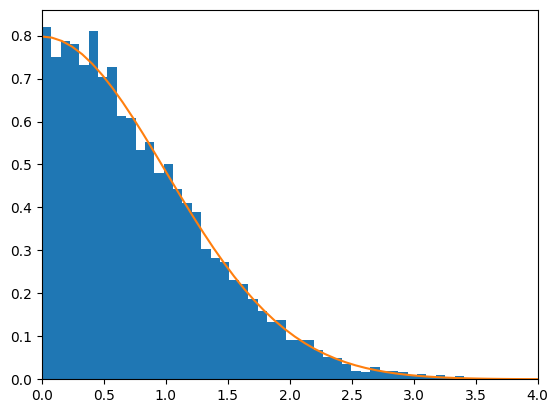

Średnia: 0.7969100164125621(0.7978845608028654)


In [61]:
def symuluj_y(u, s, n):
    X = sp.stats.norm.rvs(loc=u, scale=s, size=n)
    Y = np.absolute(X-u)
    return Y

u, s = 3, 1
Y = symuluj_y(u,s,10000)
plt.hist(Y, density=True, bins="auto")
plt.plot(np.linspace(0,4*s), 
        (sqrt(2)/(s*sqrt(pi))) * (e**(-(np.linspace(0,4*s)**2)/(2*s**2))) )
plt.xlim(0,4*s)
plt.show()
print(f"Średnia: {np.mean(Y)}({s*sqrt(2/pi)})")

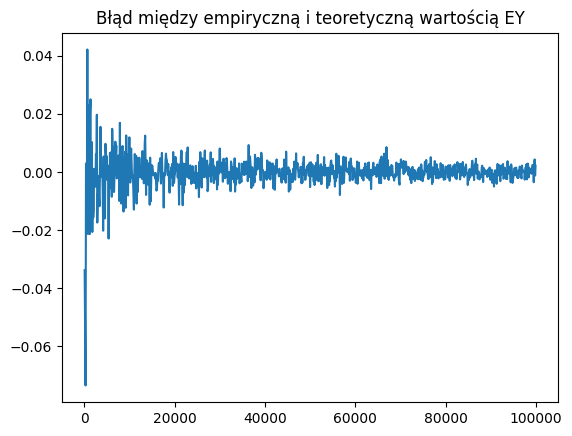

In [ ]:
u, s = 0, 1
x, y = [], []
for i in range(100, 100000, 100):
    X = sp.stats.norm.rvs(loc=u,scale=s,size=i)
    emp = np.mean(np.absolute(X-np.mean(X)))
    t = s*sqrt(2/pi)

    x.append(i)
    y.append(t-emp)

plt.plot(x,y)
plt.title("Błąd między empiryczną i teoretyczną wartością EY")
plt.show()